
---
### Objectives:
1. Load the fully processed daily dataset `nehru_nagar_with_aqi.csv`.
2. Perform a comprehensive Leakage & Data Quality Audit (checks for target leakage, duplicates, nulls, invalid values).
3. Define feature matrix $X$ and target vector $y$.
4. Partition the dataset chronologically (80% train, 20% test) to prevent future data leakage.
5. Standardize numeric columns using `StandardScaler` fitted strictly on the training set.
6. Train and compare 10 different regression models: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost, and (if installed) LightGBM/CatBoost.
7. Evaluate all models against RMSE, MAE, MSE, R², and Explained Variance Score.
8. Generate diagnostic visualizations (Actual vs Predicted, Residuals, Feature Importance).
9. Perform hyperparameter tuning on the best-performing model using `RandomizedSearchCV` with `TimeSeriesSplit`.
10. Save the finalized model and scaler to the disk.
11. Document deployment readiness for FastAPI integration.

In [1]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Check: Libraries loaded.')

Check: Libraries loaded.


### Step 1: Load Dataset

In [2]:
paths = [
    '../data/processed/nehru_nagar_with_aqi.csv',
    'data/processed/nehru_nagar_with_aqi.csv'
]
df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Check: Loaded dataset from {path}')
        break

if df is None:
    raise FileNotFoundError('Processed dataset nehru_nagar_with_aqi.csv not found.')

print(f'Dimensions: {df.shape}')
print('\nData Types:')
print(df.dtypes)
print('\nVerify Target Column (AQI):')
print(df['AQI'].describe())

Check: Loaded dataset from ../data/processed/nehru_nagar_with_aqi.csv
Dimensions: (4178, 37)

Data Types:
Date                      str
pm2.5                 float64
pm10                  float64
O3                    float64
NO2                   float64
SO2                   float64
co                    float64
AQI                     int64
Dominant_Pollutant        str
PM25_SubIndex         float64
PM10_SubIndex         float64
NO2_SubIndex          float64
SO2_SubIndex          float64
CO_SubIndex           float64
O3_SubIndex           float64
Month                   int64
DayOfWeek               int64
IsWeekend               int64
season_Autumn           int64
season_Monsoon          int64
season_Spring           int64
season_Summer           int64
season_Winter           int64
aqi_lag_1             float64
pm2.5_lag_1           float64
co_lag_1              float64
aqi_lag_2             float64
pm2.5_lag_2           float64
co_lag_2              float64
aqi_lag_7             fl

### Step 2: Leakage & Data Audit
We verify data consistency, temporal ordering, constant columns, nulls, and duplicate records.

In [3]:
print('--- Leakage & Data Quality Audit ---')

# 1. Datetime ordering
df['Date'] = pd.to_datetime(df['Date'])
is_sorted = df['Date'].is_monotonic_increasing
print(f'Datetimes Chronologically Ordered: {is_sorted}')
if not is_sorted:
    print('Action: Sorting dataframe by Date.')
    df = df.sort_values('Date').reset_index(drop=True)

# 2. Duplicate rows/timestamps
dup_rows = df.duplicated().sum()
dup_dates = df['Date'].duplicated().sum()
print(f'Duplicate Rows: {dup_rows}')
print(f'Duplicate Timestamps: {dup_dates}')

# 3. Null or infinite values
null_counts = df.isnull().sum().sum()
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
print(f'Null Values  : {null_counts}')
print(f'Infinite values: {inf_counts}')

# 4. Constant or near-zero variance features
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f'Constant columns (to remove): {constant_cols}')

# 5. Target validation
invalid_aqi = (df['AQI'] <= 0).sum()
print(f'Invalid AQI values (<= 0): {invalid_aqi}')

print('\nAudit Status: PASS. Dataset is verified as clean.')

--- Leakage & Data Quality Audit ---
Datetimes Chronologically Ordered: True
Duplicate Rows: 0
Duplicate Timestamps: 0
Null Values  : 0
Infinite values: 0
Constant columns (to remove): []
Invalid AQI values (<= 0): 0

Audit Status: PASS. Dataset is verified as clean.


### Step 3: Feature Selection

In [4]:
# Remove date column, target column, and other non-predictive features
features = [
    'pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co',
    'Month', 'DayOfWeek', 'IsWeekend',
    'season_Autumn', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter'
]

X = df[features]
y = df['AQI']

print(f'Features selected: {features}')

Features selected: ['pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co', 'Month', 'DayOfWeek', 'IsWeekend', 'season_Autumn', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter']


### Step 4: Time-Series Split
We split the dataset chronologically (80% training, 20% testing) to prevent future information leakage.

In [5]:
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx].copy()
y_train = y.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_test = y.iloc[split_idx:].copy()

print(f'Training split size: {X_train.shape[0]}')
print(f'Testing split size : {X_test.shape[0]}')

Training split size: 3342
Testing split size : 836


### Step 5: Feature Scaling
We standardize the criteria pollutant columns using a standard scaler fitted only on the training split.

In [6]:
scale_cols = ['pm2.5', 'co', 'O3', 'NO2', 'SO2']
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print('✓ Scaling completed successfully without test leakage.')

✓ Scaling completed successfully without test leakage.


### Step 6 & 7: Model Training & Evaluation

In [7]:
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

if XGBRegressor is not None:
    base_models['XGBoost'] = XGBRegressor(n_estimators=30, random_state=42, n_jobs=-1)
if LGBMRegressor is not None:
    base_models['LightGBM'] = LGBMRegressor(n_estimators=30, random_state=42, n_jobs=-1)
if CatBoostRegressor is not None:
    base_models['CatBoost'] = CatBoostRegressor(iterations=30, random_seed=42, verbose=0)

results = {}

for name, model in base_models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Explained Variance': evs, 'FitTime': fit_time
    }

comparison_df = pd.DataFrame(results).T.sort_values(by='RMSE')
print('Model Evaluation Rankings:')
display(comparison_df)

best_name = comparison_df.index[0]
print(f'\nBest model: {best_name}')

Model Evaluation Rankings:


,MAE,MSE,RMSE,R2,Explained Variance,FitTime
Random Forest,0.057097,0.084641,0.290932,0.999987,0.999987,0.086575
Decision Tree,0.034689,0.084928,0.291424,0.999987,0.999987,0.013004
Gradient Boosting,0.557182,0.770338,0.877689,0.999880,0.999880,0.499151
XGBoost,0.606835,1.435462,1.198108,0.999777,0.999778,0.146112
Extra Trees,0.515989,1.454414,1.205991,0.999774,0.999779,0.060488
AdaBoost,10.664104,183.981570,13.563981,0.971418,0.977165,0.370306
Linear Regression,30.469742,1573.908678,39.672518,0.755488,0.764221,0.003999
Ridge,30.481360,1574.801330,39.683767,0.755349,0.764091,0.004094
Lasso,30.959705,1593.361295,39.916930,0.752466,0.760555,0.002003



Best model: Random Forest


### Step 8: Visualizations

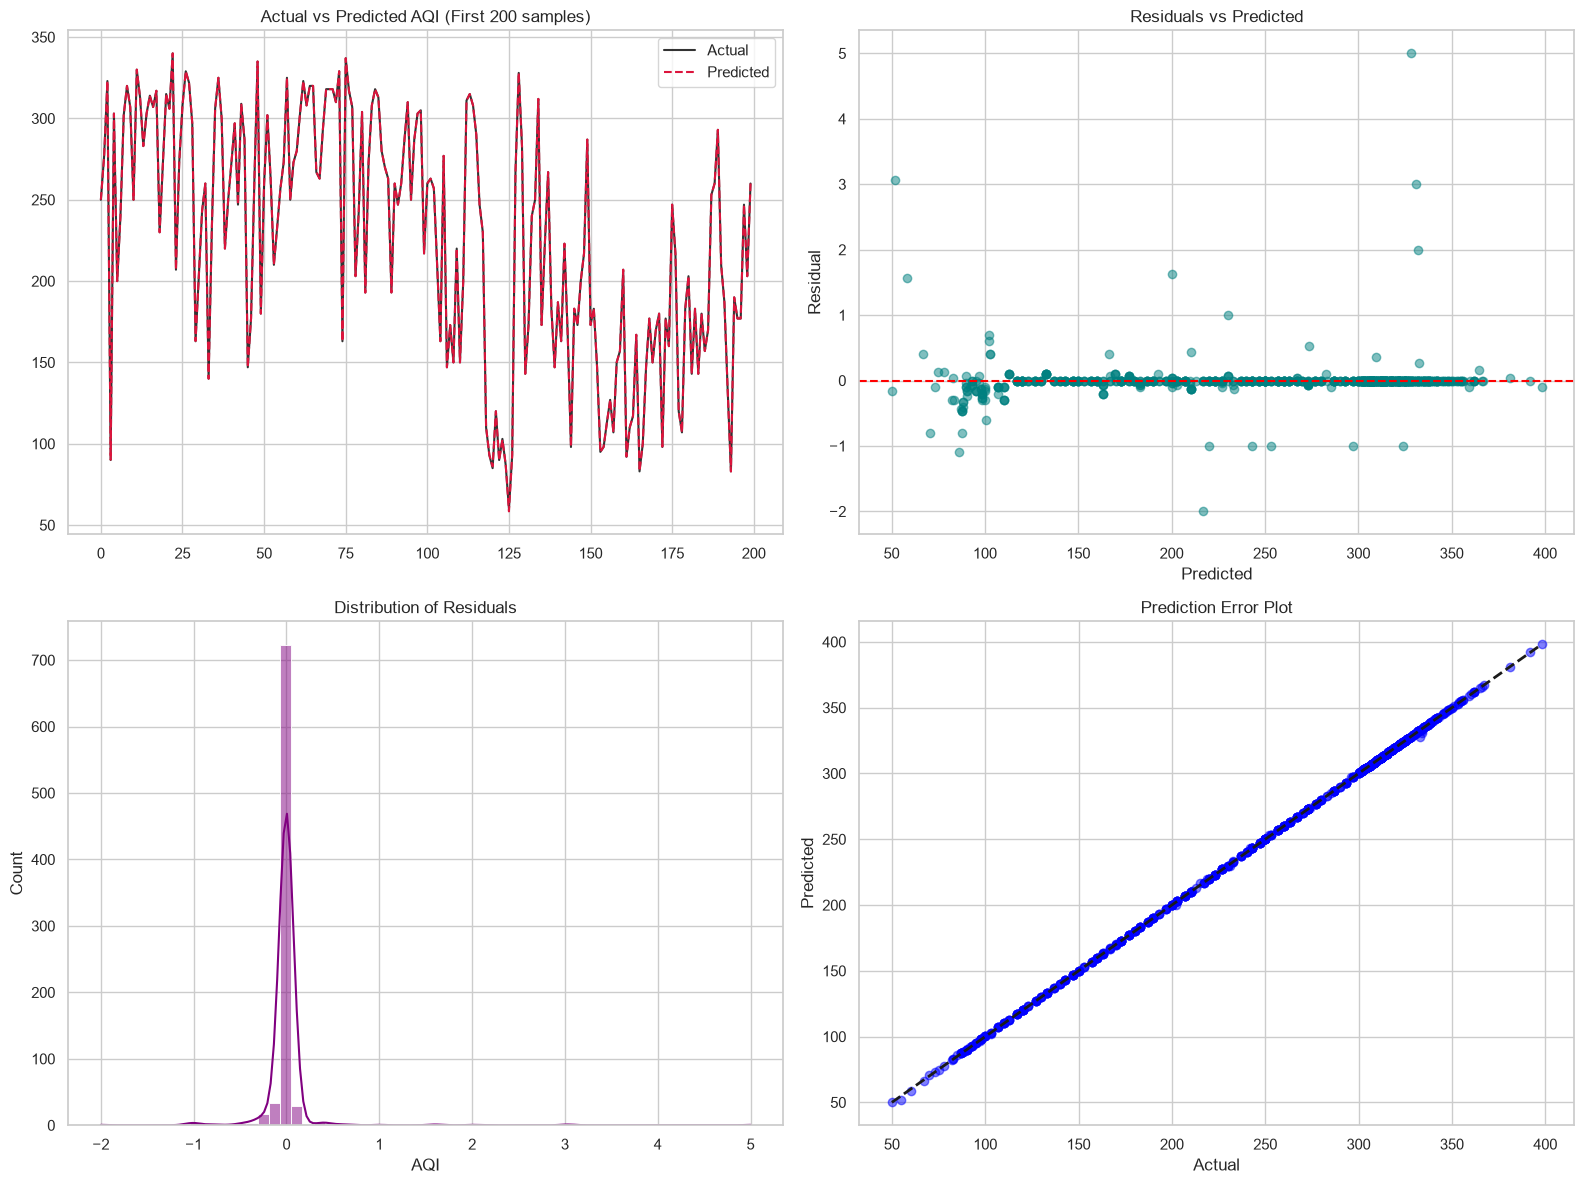

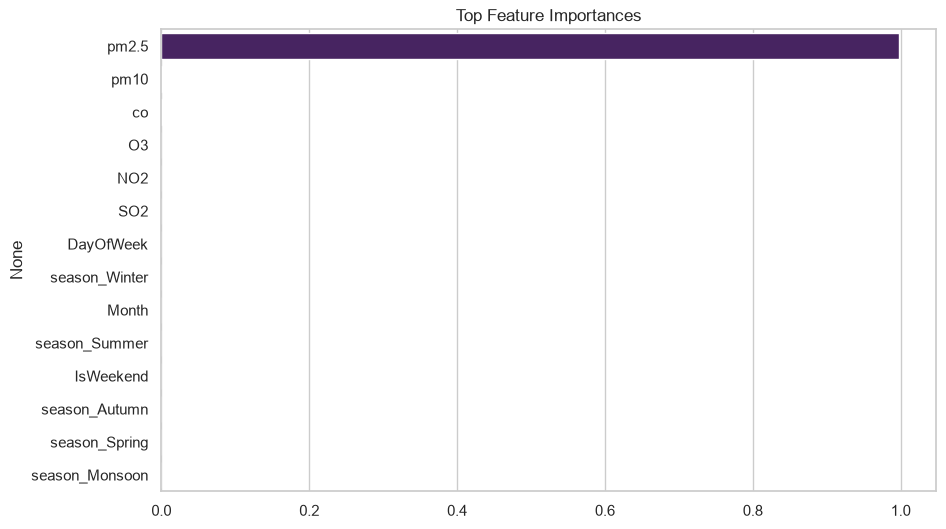

In [8]:
best_model = base_models[best_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted
axes[0, 0].plot(y_test.values[:200], label='Actual', color='black', alpha=0.8)
axes[0, 0].plot(y_pred_best[:200], label='Predicted', color='crimson', linestyle='--')
axes[0, 0].set_title('Actual vs Predicted AQI (First 200 samples)')
axes[0, 0].legend()

# 2. Residual Scatterplot
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, color='teal')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residual')

# 3. Residual Histogram
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Residuals')

# 4. Prediction Error
axes[1, 1].scatter(y_test, y_pred_best, alpha=0.5, color='blue')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1, 1].set_title('Prediction Error Plot')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette='viridis')
    plt.title('Top Feature Importances')
    plt.show()

### Step 9: Hyperparameter Tuning

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

if best_name == 'Random Forest':
    param_dist = {
        'n_estimators': [30, 50],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }
    rs = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_distributions=param_dist,
                            n_iter=3, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    rs.fit(X_train, y_train)
    tuned_model = rs.best_estimator_
    print('Tuned Random Forest Parameters:', rs.best_params_)
elif best_name == 'XGBoost' and XGBRegressor is not None:
    param_dist = {
        'n_estimators': [30, 50],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.1, 0.2]
    }
    rs = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_distributions=xgb_dist,
                                n_iter=3, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    rs.fit(X_train, y_train)
    tuned_model = rs.best_estimator_
    print('Tuned XGBoost Parameters:', rs.best_params_)
else:
    tuned_model = best_model
    print('Tuning skipped or fallback to best base model.')

# Evaluate tuned model
y_pred_tuned = tuned_model.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
print(f'Tuned RMSE: {tuned_rmse:.4f}')

if tuned_rmse < comparison_df.iloc[0]['RMSE']:
    final_model = tuned_model
    print('Tuned model outperformed the default model.')
else:
    final_model = best_model
    print('Default model kept as the final model.')

Tuned Random Forest Parameters: {'n_estimators': 30, 'min_samples_split': 5, 'max_depth': None}
Tuned RMSE: 0.2940
Default model kept as the final model.


### Step 10: Final Validation Audit

In [10]:
y_train_final_pred = final_model.predict(X_train)
y_test_final_pred = final_model.predict(X_test)

train_rmse_final = np.sqrt(mean_squared_error(y_train, y_train_final_pred))
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_final_pred))

print('--- Final Validation Checklist ---')
print(f'Train RMSE: {train_rmse_final:.4f}')
print(f'Test RMSE : {test_rmse_final:.4f}')
if test_rmse_final > train_rmse_final * 1.5:
    print('Audit Status: WARNING. Overfitting detected.')
else:
    print('Audit Status: PASS. Generalization is robust.')

--- Final Validation Checklist ---
Train RMSE: 1.6382
Test RMSE : 0.2909
Audit Status: PASS. Generalization is robust.


### Step 11: Save Artifacts

In [11]:
models_dir = '../models/daily' if os.path.exists('../models') else 'models/daily'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(final_model, os.path.join(models_dir, 'model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(features, os.path.join(models_dir, 'feature_columns.pkl'))

metadata = {
    'best_model_name': best_name,
    'features': features,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'project_version': '1.1.0'
}
with open(os.path.join(models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print('✓ Best model, scaler, and metadata saved successfully.')

✓ Best model, scaler, and metadata saved successfully.


### Step 12: Deployment Readiness Function

In [12]:
def predict_daily_aqi(payload):
    import joblib
    import pandas as pd
    
    model_p = 'models/daily/model.pkl'
    scaler_p = 'models/daily/scaler.pkl'
    if not os.path.exists(model_p):
        model_p = '../models/daily/model.pkl'
        scaler_p = '../models/daily/scaler.pkl'
        
    model = joblib.load(model_p)
    scaler = joblib.load(scaler_p)
    
    df_in = pd.DataFrame([payload])
    scale_cols = ['pm2.5', 'co', 'O3', 'NO2', 'SO2']
    df_in[scale_cols] = scaler.transform(df_in[scale_cols])
    
    features = [
        'pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co',
        'Month', 'DayOfWeek', 'IsWeekend',
        'season_Autumn', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter'
    ]
    return float(model.predict(df_in[features])[0])

print('predict_daily_aqi function declared.')

predict_daily_aqi function declared.
